### 1. Importing Requirements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from sqlalchemy import create_engine

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Database connection
DB_USER = "postgres"
DB_PASSWORD = quote_plus("Mandy@3112")   # Converts @ to %40
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "bank_dashboard"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database.")

Connected to database.


### 2. Loading all 4 Tables

In [2]:
branches = pd.read_sql("SELECT * FROM branches", engine)
customers = pd.read_sql("SELECT * FROM customers", engine)
loans = pd.read_sql("SELECT * FROM loans", engine)
transactions = pd.read_sql("SELECT * FROM transactions", engine)

print(f"Branches: {branches.shape}")
print(f"Customers: {customers.shape}")
print(f"Loans: {loans.shape}")
print(f"Transactions: {transactions.shape}")

Branches: (18, 8)
Customers: (50000, 9)
Loans: (130000, 11)
Transactions: (1500000, 7)


###  3, Missing Value Check

In [3]:
print("Missing values per table:\n")
for name, df in [("branches", branches), ("customers", customers), 
                  ("loans", loans), ("transactions", transactions)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"{name}: No missing values")
    else:
        print(f"{name}:\n{missing}\n")

Missing values per table:

branches: No missing values
customers: No missing values
loans: No missing values
transactions: No missing values


### 4. Merge Loans with Branches (Core Working Dataset)

In [4]:
loans_full = loans.merge(branches, on="branch_id", how="left")
print(loans_full.shape)
loans_full.head()

(130000, 18)


,loan_id,customer_id,branch_id,officer_id,loan_type,loan_amount,tenure_months,interest_rate,disburse_date,status,overdue_days,branch_name,city,region,performance_tier,branch_size,established_year,total_staff
0,LN0000001,CUST049965,BR009,BR009_LO5,Mortgage,2000000,240,6.61,2023-05-11,Overdue_60,69,Singapore Marina Branch,Singapore,APAC,high,flagship,1992,279
1,LN0000002,CUST033312,BR006,BR006_LO1,Business Loan,35537104,180,8.35,2022-04-12,Active,0,Zurich Branch,Zurich,Europe,high,large,1987,134
2,LN0000003,CUST018729,BR004,BR004_LO7,Working Capital Loan,39241,84,9.33,2022-05-22,Active,0,Canary Wharf Branch,London,Europe,high,flagship,1989,176
3,LN0000004,CUST024361,BR005,BR005_LO7,Business Loan,38119,60,7.53,2022-03-22,Active,0,Frankfurt Main Branch,Frankfurt,Europe,medium,large,2006,149
4,LN0000005,CUST018156,BR004,BR004_LO3,Business Loan,81325,180,9.75,2024-03-15,Active,0,Canary Wharf Branch,London,Europe,high,flagship,1989,176


### 5. NPL Rate by Branch (Bar Chart)

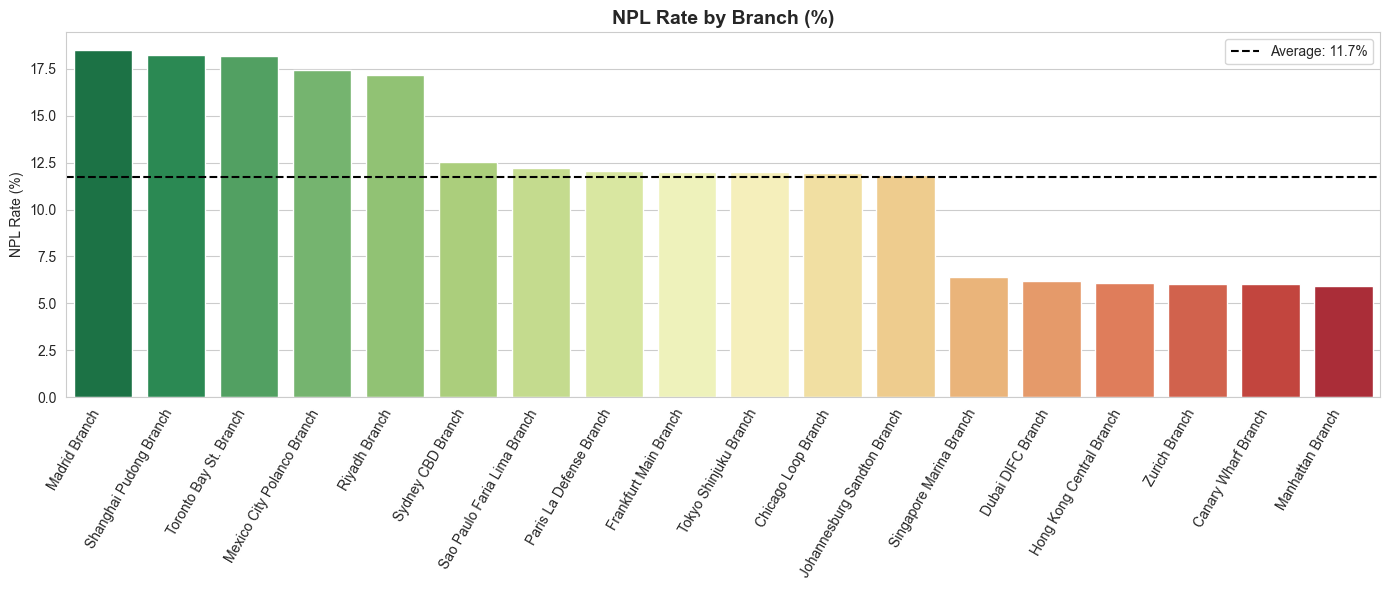

                branch_name  npl_rate_pct
              Madrid Branch     18.524395
     Shanghai Pudong Branch     18.233273
     Toronto Bay St. Branch     18.163593
 Mexico City Polanco Branch     17.434211
              Riyadh Branch     17.185909
          Sydney CBD Branch     12.547170
Sao Paulo Faria Lima Branch     12.226099
    Paris La Defense Branch     12.049664
      Frankfurt Main Branch     11.997814
      Tokyo Shinjuku Branch     11.987128
        Chicago Loop Branch     11.967921
Johannesburg Sandton Branch     11.825768
    Singapore Marina Branch      6.391573
          Dubai DIFC Branch      6.168698
   Hong Kong Central Branch      6.079717
              Zurich Branch      6.051171
        Canary Wharf Branch      6.024784
           Manhattan Branch      5.950535


In [5]:
npl_by_branch = (
    loans_full.groupby("branch_name")["status"]
    .apply(lambda x: (x == "NPL").mean() * 100)
    .reset_index(name="npl_rate_pct")
    .sort_values("npl_rate_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=npl_by_branch, x="branch_name", y="npl_rate_pct", 
            hue="branch_name", palette="RdYlGn_r", legend=False, ax=ax)
ax.axhline(npl_by_branch["npl_rate_pct"].mean(), color="black", 
           linestyle="--", label=f'Average: {npl_by_branch["npl_rate_pct"].mean():.1f}%')
ax.set_title("NPL Rate by Branch (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("NPL Rate (%)")
plt.xticks(rotation=60, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

print(npl_by_branch.to_string(index=False))

### 6. Loan Amount Distribution (Log Scale)

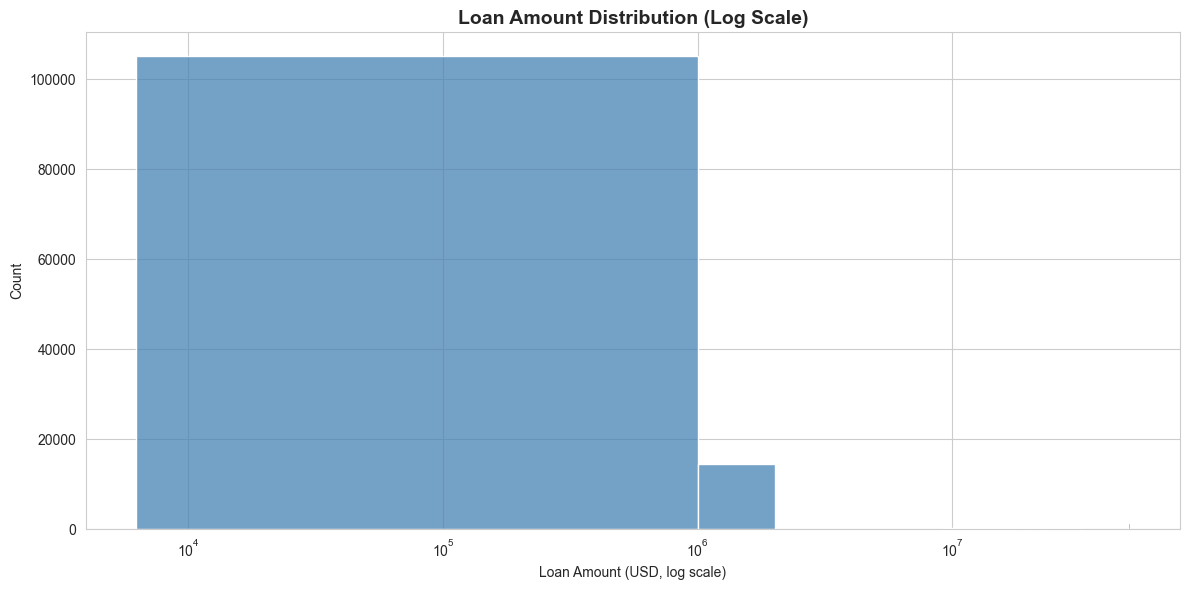

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=loans_full, x="loan_amount", hue="loan_type" if False else None, 
             bins=50, ax=ax, color="steelblue")
ax.set_xscale("log")
ax.set_title("Loan Amount Distribution (Log Scale)", fontsize=14, fontweight="bold")
ax.set_xlabel("Loan Amount (USD, log scale)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 7. Outlier Detection: Overdue Days (IQR Method)

Analyzing 25515 overdue loans (status in Overdue_30/Overdue_60/NPL)
Q1: 35.0, Q3: 173.0, IQR: 138.0
Outlier bounds: [-172.0, 380.0]
Number of outliers: 1120 (4.39% of overdue loans)


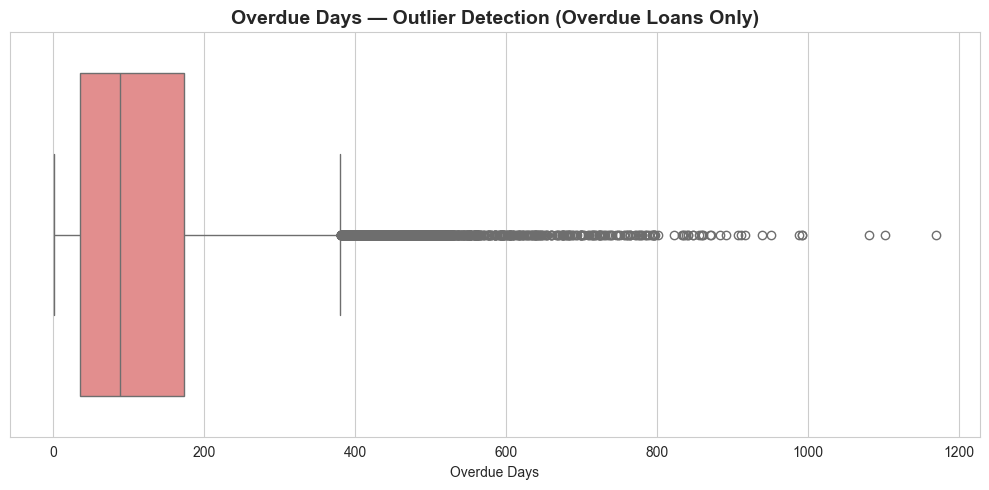

In [7]:
# Filter to only loans that are actually overdue/delinquent
overdue_loans = loans[loans["status"].isin(["Overdue_30", "Overdue_60", "NPL"])]

Q1 = overdue_loans["overdue_days"].quantile(0.25)
Q3 = overdue_loans["overdue_days"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = overdue_loans[
    (overdue_loans["overdue_days"] < lower_bound) | 
    (overdue_loans["overdue_days"] > upper_bound)
]

print(f"Analyzing {len(overdue_loans)} overdue loans (status in Overdue_30/Overdue_60/NPL)")
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Outlier bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(overdue_loans)*100:.2f}% of overdue loans)")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=overdue_loans["overdue_days"], ax=ax, color="lightcoral")
ax.set_title("Overdue Days — Outlier Detection (Overdue Loans Only)", fontsize=14, fontweight="bold")
ax.set_xlabel("Overdue Days")
plt.tight_layout()
plt.show()

### 8.  Monthly Transaction Trend (Time Series)

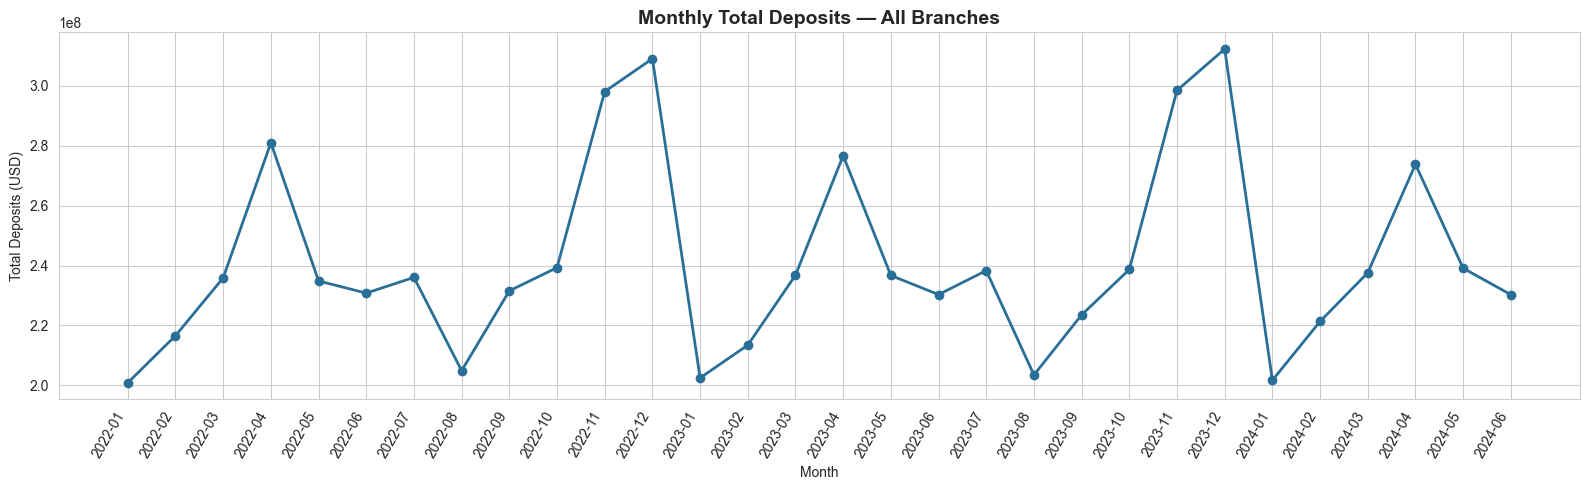

In [8]:
transactions["txn_date"] = pd.to_datetime(transactions["txn_date"])
transactions["month"] = transactions["txn_date"].dt.to_period("M")

monthly_deposits = (
    transactions[transactions["txn_type"] == "deposit"]
    .groupby("month")["amount"]
    .sum()
    .reset_index()
)
monthly_deposits["month"] = monthly_deposits["month"].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_deposits["month"], monthly_deposits["amount"], 
        marker="o", color="#2a6f97", linewidth=2)
ax.set_title("Monthly Total Deposits — All Branches", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Deposits (USD)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### 9. Correlation Heatmap (Numeric Features)

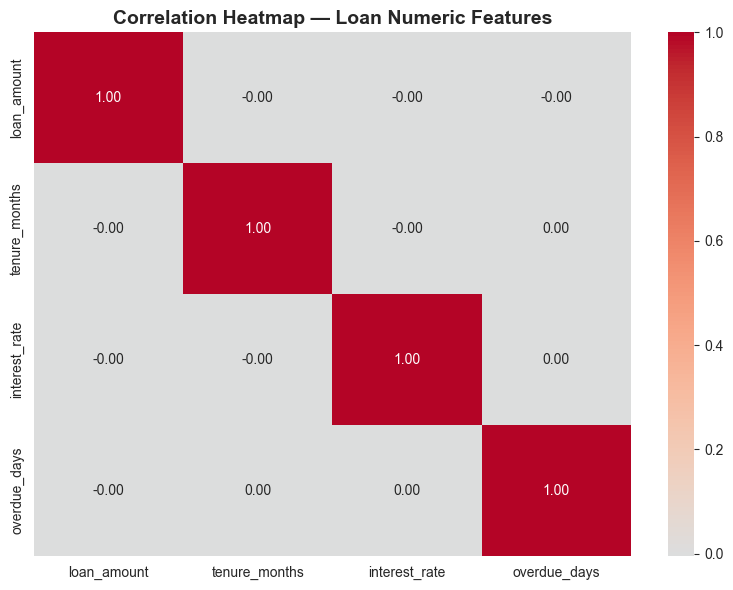

In [9]:
numeric_cols = loans[["loan_amount", "tenure_months", "interest_rate", "overdue_days"]]
corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap — Loan Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Key Findings

1. **NPL Rate by Branch:** Branch performance tiers strongly predict loan risk. Low-tier 
   branches (Madrid 18.5%, Shanghai 18.2%, Toronto 18.2%, Mexico City 17.4%, Riyadh 17.2%) 
   sit well above the branch-level average of 11.7%, medium-tier branches cluster around 
   12%, and high-tier branches (Singapore, Dubai, Hong Kong, Zurich, Canary Wharf, 
   Manhattan) sit around 6%. This branch-average NPL rate (11.7%) differs from the 
   loan-volume-weighted overall rate (9.71%) because flagship branches process far more 
   loans and carry lower NPL rates, pulling the volume-weighted average down.

2. **Loan Distribution:** Loan amounts are right-skewed with a log-normal shape, 
   reflecting the mix of smaller retail/SME loans and a smaller cluster of large 
   corporate facilities.

3. **Outlier Detection (Corrected):** Initial IQR analysis on the full loan population 
   was invalid due to zero-inflation (~88% of loans have overdue_days = 0, collapsing 
   Q1/Q3 to 0). After isolating the 25,515 genuinely overdue loans (status in 
   Overdue_30/Overdue_60/NPL), IQR analysis produced valid bounds: Q1 = 35 days, 
   Q3 = 173 days, IQR = 138 days, with an upper bound of 380 days. This flagged 1,120 
   loans (4.39% of overdue loans) as statistical outliers — representing the most 
   severely delinquent accounts in the portfolio, with overdue periods extending well 
   beyond the typical 35-173 day range.

4. **Seasonal Deposits:** Monthly deposit totals show clear seasonality, peaking in 
   Nov-Dec (holiday season) and April (Q1 close/bonus season), with dips in January — 
   confirming the seasonal multipliers built into the synthetic data generator.

5. **Correlation Heatmap:** Near-zero correlation across loan_amount, tenure_months, 
   interest_rate, and overdue_days is expected, since these fields were generated 
   independently with no engineered relationship in this synthetic dataset. In real 
   banking data, some correlation (e.g., higher interest rates on higher-risk loans) 
   would typically be expected.

6. **Next Step:** These findings directly inform the SQL transformation layer — 
   specifically the branch-level NPL rate view, customer risk segmentation logic, and 
   the MoM deposit growth window function.